# Matching Distance

Matching distance compares two 2-parameter persistence modules by looking at
all 1-parameter slices. For an affine line
$\ell(t)=b+t v$ with strictly positive direction $v\in\mathbb R^2_{>0}$,
write $M^\ell$ for the restriction of $M$ to that line. This restriction is
an ordinary 1-parameter persistence module, so it has an ordinary barcode
$\mathcal B(M^\ell)$.

The exact matching distance is the supremum of weighted bottleneck distances
between these [fibered barcodes](../invariants/fibered_barcode.ipynb):

$$
d_\mathrm{match}(M,N)
=
\sup_\ell w(\ell)\,
d_B\bigl(\mathcal B(M^\ell),\mathcal B(N^\ell)\bigr),
\qquad
w(\ell)=\frac{\min_i v_i}{\max_i v_i}.
$$

The weight makes the value invariant under rescaling the line direction and is
the factor behind the stability bound $d_\mathrm{match}(M,N)\le d_I(M,N)$.
This is the same fibered-barcode viewpoint used in RIVET-style visualization:
sweep positive-slope lines through the parameter plane, then inspect the
ordinary barcode on each line.

The Monte Carlo backend below samples finitely many lines $\ell_j(t)=b_j+t v_j$.
Sampled directions are normalized by $\max_i v_{j,i}=1$, so the weight used in
code is $w(v_j)=\min_i v_{j,i}$. With the default `mc_line_reduction="max"`,
the estimate is

$$
\widehat d(M,N)=
\max_{1\le j\le m}
\min_i v_{j,i}\,
d_B\bigl(\mathcal B(M^{\ell_j}),\mathcal B(N^{\ell_j})\bigr).
$$

If `mc_wp` is finite, the per-line barcode distance is Wasserstein-$p$ instead
of bottleneck. Other `mc_line_reduction` values (`"mean"`, `"l<p>"`,
`"softmax"`) replace the final max over sampled lines; they are smoothing or
averaging choices, not the mathematical matching distance.

In [1]:
import numpy as np

import multipers as mp
import matplotlib.pylab as plt
from sklearn.datasets import make_blobs
from multipers.distances import matching_distance

We compare two blob point clouds with many fewer points than the integral-distance
notebook because Delaunay core bifiltrations grow quickly. The two clouds share
cluster centers but differ in spread.

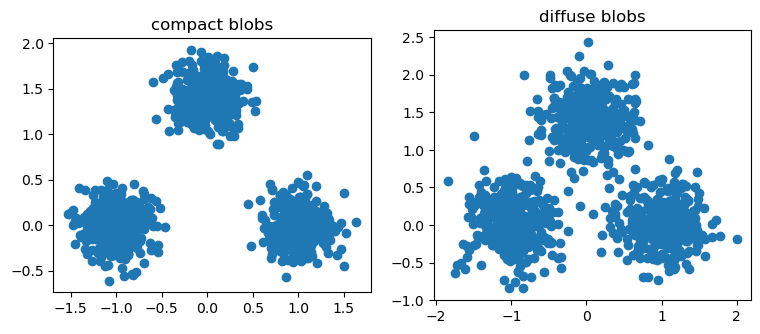

In [2]:
np.random.seed(0)
centers = [(-1.0, 0.0), (1.0, 0.0), (0.0, 1.4)]
X = np.asarray(make_blobs(n_samples=1000, centers=centers, cluster_std=0.2, random_state=0)[0])
Y = np.asarray(make_blobs(n_samples=1000, centers=centers, cluster_std=0.3, random_state=1)[0])

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
a.scatter(*X.T)
a.set_aspect(1)
a.set_title("compact blobs")

b.scatter(*Y.T)
b.set_aspect(1)
b.set_title("diffuse blobs")
plt.show()

Build Delaunay core bifiltrations for both point clouds. `CoreDelaunay`
constructs the Delaunay-size version of the core bifiltration; see the
[Delaunay Core Bifiltration](../filtrations/delaunay_core_bifiltration.ipynb)
notebook for construction details. Passing a short `ks` list keeps the density axis coarse
and avoids building the full `1,\dots,n` family. `CoreDelaunay` is
multi-critical, but `matching_distance` can restrict to the selected degree directly.
We keep the default alpha range; a too-small
`max_alpha_square` can leave unmatched essential bars and make the
bottleneck distance infinite.

In [3]:
ks = np.unique(np.linspace(1, min(len(X), len(Y)) // 2, num=200, dtype=int)).tolist()
beta = 0.5

left = mp.filtrations.CoreDelaunay(
    points=X,
    beta=beta,
    ks=ks,
)
right = mp.filtrations.CoreDelaunay(
    points=Y,
    beta=beta,
    ks=ks,
)

For visualization only, we turn the multicritical filtrations into
[one-critical](../ops/multicritical_free_implicit_resolution.ipynb)
[minimal presentations](../ops/minimal_presentations_resolutions.ipynb) in the
selected degree and approximate the corresponding modules.
This step is not needed by `matching_distance`, which accepts the raw
`CoreDelaunay` filtrations together with the selected `degree`.

In [4]:
degree = 0
left_oc = mp.ops.one_criticalify(left, degree=degree)
right_oc = mp.ops.one_criticalify(right, degree=degree)


def renormalize_slicer(slicer, box):
    box = np.asarray(box, dtype=float)
    scale = box[1] - box[0]
    scale[scale == 0] = 1
    filtrations = (np.asarray(slicer.get_filtrations(), dtype=float) - box[0]) / scale
    out = mp.Slicer(slicer, return_type_only=True)(
        slicer.get_boundaries(),
        slicer.get_dimensions(),
        filtrations,
    )
    out._mark_minpres(slicer.minpres_degree, is_minres=slicer.is_minres)
    return out


box = mp.grids.compute_bounding_box_from_iterable([left_oc, right_oc])
left_oc = renormalize_slicer(left_oc, box)
right_oc = renormalize_slicer(right_oc, box)
box = np.asarray([[0, 0], [1, 1]], dtype=float)

left_mma = mp.module_approximation(
    left_oc,
    from_coordinates=True,
    direction=[1, 0],
    swap_box_coords=[1],
)
right_mma = mp.module_approximation(
    right_oc,
    from_coordinates=True,
    direction=[1, 0],
    swap_box_coords=[1],
)

/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/logs.py:117: GeometryWarning: Got a degenerate direction. This function may fail if the first line is not generic. 
Set `multipers.logs.GeometryWarning.enabled = False` to disable this warning.
  _emit("geometry", message, stacklevel=stacklevel)
/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/logs.py:117: GeometryWarning: Got a degenerate direction. This function may fail if the first line is not generic.
  _emit("geometry", message, stacklevel=stacklevel)


Draw a small deterministic set of positive-slope lines. For each line, a
one-line call to `matching_distance` computes the ordinary persistence on that
line for both modules and returns the weighted bottleneck score
$w(v)d_B(\mathcal B(M^\ell),\mathcal B(N^\ell))$.

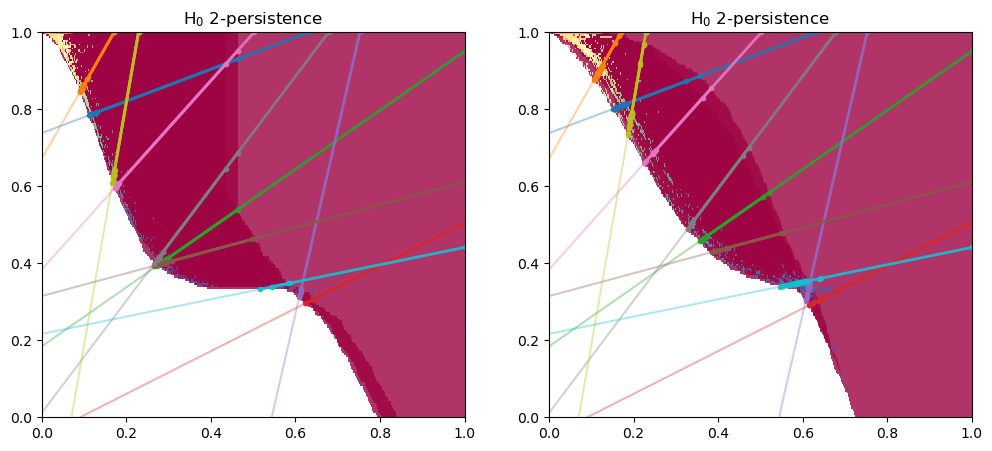

np.float64(0.17103873539056788)

In [5]:
num_lines = 10
rng = np.random.default_rng(1)
line_basepoints = rng.uniform(low=box[0], high=box[1], size=(num_lines, 2))
line_directions = rng.uniform(low=0.05, high=1, size=(num_lines, 2))
line_directions /= line_directions.max(axis=1, keepdims=True)


def degree_bars(module, basepoint, direction, degree=1):
    bars_by_degree = module.barcode2(
        basepoint=basepoint,
        direction=direction,
    )
    if len(bars_by_degree) <= degree:
        return np.empty((0, 2))
    return np.asarray(bars_by_degree[degree]).reshape(-1, 2)


def draw_barcode_slices(ax, module):
    alpha=.9
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(line_basepoints)))
    for basepoint, direction, color in zip(line_basepoints, line_directions, colors):
        ax.axline(basepoint, slope=direction[1] / direction[0], color=color, alpha=0.35)
        for bar in degree_bars(module, basepoint, direction, degree):
            finite_bar = np.isfinite(bar)
            if finite_bar.all():
                segment = basepoint[None] + direction[None] * bar[:, None]
                ax.plot(segment[:, 0], segment[:, 1], "o-", color=color, lw=2, ms=3, alpha=alpha)
            elif finite_bar[0]:
                death = np.min((box[1] - basepoint) / direction)
                segment = basepoint[None] + direction[None] * np.array([bar[0], death])[:, None]
                ax.plot(segment[:, 0], segment[:, 1], "o-", color=color, lw=2, ms=3, alpha=alpha)


fig, (a, b) = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(a)
left_mma.plot(degree=degree, box=box)
draw_barcode_slices(a, left_mma)

plt.sca(b)
right_mma.plot(degree=degree, box=box)
draw_barcode_slices(b, right_mma)
plt.show()

line_scores = []
line_stats = []
for basepoint, direction in zip(line_basepoints, line_directions):
    score, stat = matching_distance(
        left_oc,
        right_oc,
        degree=degree,
        strategy="monte_carlo",
        mc_basepoints=basepoint[None],
        mc_directions=direction[None],
        mc_nlines=1,
        mc_line_reduction="max",
        return_stats=True,
    )
    line_scores.append(score)
    line_stats.append(stat)

line_scores = np.asarray(line_scores)
best_line_index = int(np.argmax(line_scores))
line_scores[best_line_index] # this is a lower bound



In [6]:
matching_distance(
    left_oc,
    right_oc,
    mc_nlines=500,
    degree=degree,
    strategy="monte_carlo",
) # a better lower bound

0.19965623079516423

The `hera` backend uses the algorithm of Kerber and Nigmetov
{cite:p}`kerberEfficientApproximationMatching2020`: in dimension two, it
parameterizes the four families of positive-slope lines, evaluates the weighted
bottleneck distance at the center of adaptive quadtree boxes, and uses geometric
upper bounds on each box to refine only where the current maximum can still
improve. This gives a certified approximation error, reported by
`return_stats=True` as `actual_error`. In `multipers`, this backend is usually
slower and requires 2-parameter one-critical presentations. The Monte Carlo
strategy used here does not certify the error: it only returns a lower bound
over the sampled lines. In exchange, Monte Carlo is often faster and applies in
any parameter dimension.

Reference: Kerber, Nigmetov, Cabello, and Chen, *Efficient Approximation of the
Matching Distance for 2-Parameter Persistence*, SoCG 2020.
DOI: https://doi.org/10.4230/LIPIcs.SoCG.2020.53

In [9]:
# A provable approximation of the matching distance
matching_distance(
    left_oc,
    right_oc,
    degree=degree,
    strategy="hera",
    epsilon=.1,
    delta=.1,
) 

0.19868078843908593